## Collect data

In [3]:
import os
import pandas as pd
import numpy as np
data_dir = '/cosma8/data/do012/dc-he4/analysis'

datadict = {}
for lc in range(1728):
    lc00 = f'{lc:04d}'

    filename = f'{data_dir}/lc{lc00}/h0mc_joint_random.csv'

    # check if file exists
    if os.path.exists(filename):
        df = pd.read_csv(filename)

        # save to df
        if 'delta' not in list(datadict.keys()):  # datadict.keys() is of type dict_keys
            for key in df.keys():           # load all data
                datadict[key] = df[key]

            length = len(df[key])           # register lightcone number
            datadict['Lightcone'] = np.full(length, lc)
        else:
            for key in df.keys():           # load all data
                datadict[key] = np.concatenate((datadict[key], df[key]))

            length = len(df[key])           # register lightcone number
            datadict['Lightcone'] = np.concatenate((datadict['Lightcone'], np.full(length, lc)))

    else:
        print(lc00, 'h0mc_joint_random.csv not found.')
        continue
    
data = pd.DataFrame(datadict)

data

0000 h0mc_joint_random.csv not found.
0001 h0mc_joint_random.csv not found.
0002 h0mc_joint_random.csv not found.
0003 h0mc_joint_random.csv not found.
0004 h0mc_joint_random.csv not found.
0005 h0mc_joint_random.csv not found.
0006 h0mc_joint_random.csv not found.
0007 h0mc_joint_random.csv not found.
0008 h0mc_joint_random.csv not found.
0009 h0mc_joint_random.csv not found.
0010 h0mc_joint_random.csv not found.
0011 h0mc_joint_random.csv not found.
0012 h0mc_joint_random.csv not found.
0013 h0mc_joint_random.csv not found.
0014 h0mc_joint_random.csv not found.
0015 h0mc_joint_random.csv not found.
0016 h0mc_joint_random.csv not found.
0017 h0mc_joint_random.csv not found.
0018 h0mc_joint_random.csv not found.
0019 h0mc_joint_random.csv not found.
0020 h0mc_joint_random.csv not found.
0021 h0mc_joint_random.csv not found.
0022 h0mc_joint_random.csv not found.
0023 h0mc_joint_random.csv not found.
0024 h0mc_joint_random.csv not found.
0025 h0mc_joint_random.csv not found.
0026 h0mc_jo

""


In [4]:
# Get the significance
significance = data['delta'] / data['delta_err_lower']
data['Significance'] = significance
data['DeltaH0'] = data['delta'] * 2 * 100 # to percentage
data.to_csv('../data/analysis_all/h0_mc_joint_random.csv')

KeyError: 'delta'

## Load functions

In [ ]:
# ---------------------------------------------------------------------------- #
#                                   Functions                                  #
# ---------------------------------------------------------------------------- #
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
from scipy.stats import genpareto
import matplotlib.pyplot as plt
from scipy.special import erfinv
import math
import clusterplot as cp
plt.style.use('./nice.mplstyle')

def load_data(file_path, data_type='mc'):
    data = pd.read_csv(file_path)
    if data_type == 'direct_compare':
        data['Delta_H0'] *= 100
    return data

def extract_data(data, relation):
    df = data[data['Relations'] == relation]
    if 'Delta_H0' in df.columns:
        delta_h0 = df['Delta_H0'].values
    else:
        delta_h0 = df['$\Delta H_0\,(\%)$'].values
    if 'Significance $(\sigma)$' in df.columns:
        significance = df['Significance $(\sigma)$'].values
    else:
        significance = df['Significance'].values
    return delta_h0, significance

def calculate_sigma_p_value(delta_h0_proj, target_value):
    median = np.median(delta_h0_proj)
    sigma_84th = np.percentile(delta_h0_proj, 84)
    sigma = sigma_84th - median
    sigma_deviation = np.abs((target_value - median) / sigma)
    p_value_sigma = 1 - math.erf(sigma_deviation / np.sqrt(2))
    return sigma_deviation, p_value_sigma

def calculate_evt_p_value(delta_h0_proj, target_value, percentile=90):
    # Determine the threshold
    threshold = np.percentile(delta_h0_proj, percentile)
    exceedances = delta_h0_proj[delta_h0_proj > threshold] - threshold  # Tail data

    # Fit GPD to the tail data
    params = genpareto.fit(exceedances)
    shape, loc, scale = params

    # Tail survival probability (proportion of data in the tail)
    tail_prob = np.sum(delta_h0_proj >= threshold) / len(delta_h0_proj)

    if target_value > threshold:
        # Conditional probability adjusted to match at the threshold
        p_value_evt = (1 - genpareto.cdf(target_value - threshold, *params)) * tail_prob
    else:
        # Empirical CDF for the bulk region
        p_value_evt = np.sum(delta_h0_proj >= target_value) / len(delta_h0_proj)

    # Transform to sigma (Gaussian equivalent deviation)
    sigma_deviation = np.sqrt(2) * erfinv(1 - p_value_evt)

    return p_value_evt, sigma_deviation

# The first projection function
def default_proj(delta_H0, n_sigma):
    return delta_H0 - delta_H0 / n_sigma

/cosma/home/do012/dc-he4/.conda/envs/halo-cosma/lib/python3.8/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


## Small plots for appendices
The MCMC run, for Lx-T and Ysz-T, output data and plot.

Prob of obtaining (ΔH%, nσ) = [8.7 2.4] in $L_\mathrm{{X}}-T$.
Sigma deviation: 2.88σ, p-value: 0.00403
Probability of target value: 0.0322, (2.14sigma)


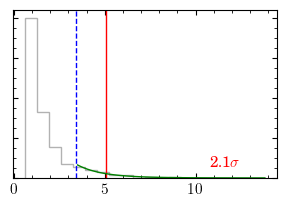

Prob of obtaining (ΔH%, nσ) = [14.   2.6] in $Y_\mathrm{{SZ}}-T$.
Sigma deviation: 9.26σ, p-value: 0
Probability of target value: 0.000276, (3.64sigma)


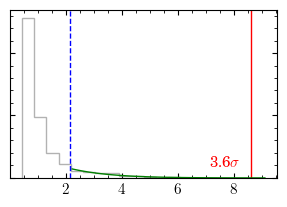

In [ ]:
file_path_mc = '/cosma/home/do012/dc-he4/anisotropy-flamingo/data/analysis_all/h0_mc_joint_random.csv'
data_type_mc = 'mc'
data_mc = load_data(file_path_mc, data_type_mc)

target_point_arr_mc = [np.array([8.7, 2.4]), np.array([14, 2.6])]
for relation, target_point in zip(['$L_\\mathrm{{X}}-T$', '$Y_\\mathrm{{SZ}}-T$'], target_point_arr_mc):
    print(f'Prob of obtaining (ΔH%, nσ) = {target_point} in {relation}.')
    delta_h0, significance = extract_data(data_mc, relation)
    delta_h0_proj = default_proj(delta_h0, significance)
    target_value = default_proj(target_point[0], target_point[1])
    
    sigma_deviation, p_value_sigma = calculate_sigma_p_value(delta_h0_proj, target_value)
    print(f"Sigma deviation: {sigma_deviation:.3g}σ, p-value: {p_value_sigma:.3g}")
    
    percentile = 90
    p_value_evt, sigma_evt = calculate_evt_p_value(delta_h0_proj, target_value, percentile)
    print(f"Probability of target value: {p_value_evt:.3g}, ({sigma_evt:.3g}sigma)")
    
    threshold = np.percentile(delta_h0_proj, percentile)
    exceedances = delta_h0_proj[delta_h0_proj > threshold] - threshold
    params = genpareto.fit(exceedances)
    shape, loc, scale = params
    
    # Plotting results
    x_vals = np.linspace(threshold, delta_h0_proj.max(), 100)
    gpd_pdf = genpareto.pdf(x_vals - threshold, shape, loc, scale) * (1 - percentile / 100)

    # Plot
    cp._small_evs_(distribution=delta_h0_proj,
                   target_value=target_value,
                   x_vals=x_vals,
                   gpd_pdf=gpd_pdf,
                   threshold=threshold,
                   percentile=percentile,
                   sigma_evt=sigma_evt, color='gray')

    # plt.savefig(f'./to_paper/evs_mcmc_{relation[1]}.pdf', bbox_inches='tight')   # save the figure
    plt.show()

## Main results

In [ ]:
file_path_joint = '../data/analysis_all/h0_mc_joint_random.csv'
data_joint = load_data(file_path_joint, 'joint')
data_joint = data_joint[data_joint['Lightcone'] != 1318]
print(len(data_joint))
# lightcone 1318 is bugged

1726


In [ ]:
# Which ones are not there?
for i in range(1728):
    if i in data_joint['Lightcone'].values:
        continue
    else:
        print(i)

1215
1318


### Bootstrap resampling error

In [ ]:
def bootstrap_fit(data, fit_func=genpareto.fit, N=1000):
    # Bootstrap sampling
    all_params = []
    for i in range(N):
        sample = np.random.choice(data, size=len(data), replace=True)
        params = fit_func(sample)
        all_params.append(params)
    all_params = np.array(all_params)

    # Lower and upper one sigma parameters
    lower_params = np.zeros_like(params)
    upper_params = np.zeros_like(params)
    for i in range(len(params)):
        lower_params[i] = np.percentile(a=all_params[:,i], q=16)
        upper_params[i] = np.percentile(a=all_params[:,i], q=84)
        
    return lower_params, upper_params
    

In [ ]:
# ** This plot is put in the paper **
target_point = np.array([9.0, 5.9])

print(f'Prob of obtaining (ΔH%, nσ) = {target_point} in joint result.')
delta_h0 = data_joint['DeltaH0'].values
significance = data_joint['Significance'].values
delta_h0_proj = default_proj(delta_h0, significance)
target_value = default_proj(target_point[0], target_point[1])

sigma_deviation, p_value_sigma = calculate_sigma_p_value(delta_h0_proj, target_value)
print(f"Sigma deviation: {sigma_deviation:.3g}σ, p-value: {p_value_sigma:.3g}")

percentile = 90
p_value_evt, sigma_evt = calculate_evt_p_value(delta_h0_proj, target_value, percentile)
print(f"Probability of target value: {p_value_evt:.3g}, ({sigma_evt:.3g}sigma)")

threshold = np.percentile(delta_h0_proj, percentile)                           # get the threshold                  
exceedances = delta_h0_proj[delta_h0_proj > threshold] - threshold # select the exceedance

params = genpareto.fit(exceedances)    # make the genpareto fit
shape, loc, scale = params # extract the parameters

# error bar
params_lower, params_upper = bootstrap_fit(exceedances)
print('fit params:', params_lower, 'to', params_upper)

Prob of obtaining (ΔH%, nσ) = [9.  5.9] in joint result.
Sigma deviation: 6.2σ, p-value: 5.63e-10
Probability of target value: 0.000155, (3.78sigma)


fit params: [-0.2891641   0.00397429  1.24048601] to [-0.12274693  0.03153765  1.57062138]


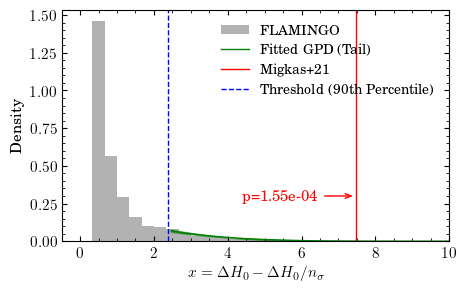

In [ ]:
x_vals = np.linspace(threshold, 10, 100) # x for plotting fitted pdf
gpd_pdf = genpareto.pdf(x_vals - threshold, shape, loc, scale) * (1 - percentile / 100) # fitted genpareto distribution
gpd_pdf0 = genpareto.pdf(x_vals - threshold, *params_lower) * (1 - percentile / 100) # lower bound
gpd_pdf1 = genpareto.pdf(x_vals - threshold, *params_upper) * (1 - percentile / 100) # upper bound

# Plotting results for joint result
plt.figure(figsize=(5, 3))
plt.hist(delta_h0_proj, bins=30, range=(0, 10), density=True, alpha=0.6, color='gray', label='FLAMINGO')   # histogram

plt.plot(x_vals[1:], gpd_pdf[1:], color='g', label='Fitted GPD (Tail)')                                    # fitted line
plt.fill_between(x_vals[1:], gpd_pdf0[1:], gpd_pdf1[1:], color='g', alpha=0.5)

plt.axvline(target_value, color='red', linestyle='-', label=f'Migkas+21')                                  # M21 reference line
plt.axvline(threshold, color='blue', linestyle='--', label=f'Threshold ({percentile}th Percentile)') # threshold reference line

# Annotate the plot
plt.annotate(f'p={p_value_evt:.2e}', 
         xy=(target_value, 0.3), xycoords='data',
         xytext=(target_value - 1, 0.3), textcoords='data',
         arrowprops=dict(arrowstyle='->,head_width=.15', color='red'),
         horizontalalignment='right', verticalalignment='center', color='red')

plt.xlabel('$x=\\Delta H_0 - \\Delta H_0 / n_\\sigma$')
plt.ylabel('Density')
plt.xlim(right=10)
# plt.yscale('log')
plt.legend(fontsize=10)

# plt.savefig('./to_paper/evs_joint.pdf', bbox_inches='tight')
plt.show()

In [ ]:
print('fit params:', params_lower, 'to', params_upper)

fit params: [-0.2943012   0.00397429  1.23647083] to [-0.13222544  0.03153765  1.56657188]
